# Homework 10b — Modeling: Time Series & Classification

## Objective

This notebook builds a **time-aware classification baseline** to predict whether the **next-step return is positive (`up`) or non-positive (`down`)**.

It follows the Stage 10b starter workflow:

**Data → Features → Target → Split → Pipeline → Metrics → Interpretation**

The submission uses the **synthetic time series supplied in the homework starter**. The generator includes changing return/volatility regimes and occasional jumps, which makes it useful for demonstrating why a model can be technically correct yet still have limited predictive reliability.

### What this notebook demonstrates

- leakage-safe lag and rolling features
- a chronological 80/20 train/test split
- an sklearn `Pipeline` with preprocessing and logistic regression
- accuracy, precision, recall, F1, and confusion matrix
- a majority-class benchmark
- time-series cross-validation as a robustness check
- risk-aware interpretation of what works and what fails

**Reproducibility:** all randomness uses seed `7`.

**Source note:** the synthetic data-generating process is adapted from the course-provided Stage 10b homework starter; the feature set, validation, diagnostics, comparisons, and interpretations are developed for this submission.


## 1. Imports and reproducibility

The classification model is logistic regression inside an sklearn `Pipeline`.

`StandardScaler` is fit **only on the training portion** because it is inside the pipeline. This is important: scaling the full dataset before splitting would leak information from the future test period into model training.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    make_scorer,
    roc_auc_score,
)

SEED = 7
np.random.seed(SEED)

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print(f"Random seed: {SEED}")


Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\yifunger\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


Random seed: 7


## 2. Data

The starter generator creates 500 business-day observations with:

- a lower-volatility first regime,
- a higher-volatility second regime,
- a small change in expected return,
- five random jump days.

This matters for modeling because a fixed statistical relationship may not remain stable when the data-generating regime changes.


In [2]:
# Synthetic series with regimes and jumps, adapted from the course starter
n = 500
dates = pd.bdate_range("2021-01-01", periods=n)

mu = np.where(np.arange(n) < n // 2, 0.0003, -0.0001)
sigma = np.where(np.arange(n) < n // 2, 0.010, 0.015)

eps = np.random.normal(mu, sigma)

jumps = np.zeros(n)
jump_days = np.random.choice(np.arange(20, n - 20), size=5, replace=False)
jumps[jump_days] = np.random.normal(0, 0.05, size=len(jump_days))

rets = eps + jumps
price = 100 * np.exp(np.cumsum(rets))

df = pd.DataFrame({"price": price}, index=dates)
df.index.name = "date"

# pct_change is observable after each day's close.
df["ret"] = df["price"].pct_change()
df["log_ret"] = np.log1p(df["ret"])

print("Raw shape:", df.shape)
df.head()


Raw shape: (500, 3)


,price,ret,log_ret
date,,,
2021-01-01,101.7354,NaN,NaN
2021-01-04,101.2929,-0.0043,-0.0044
2021-01-05,101.3565,0.0006,0.0006
2021-01-06,101.8009,0.0044,0.0044
2021-01-07,101.0313,-0.0076,-0.0076


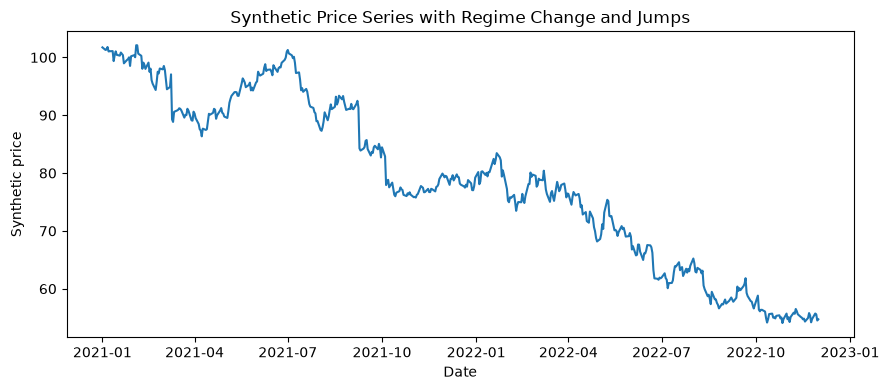

In [3]:
plt.figure(figsize=(9, 4))
plt.plot(df.index, df["price"])
plt.xlabel("Date")
plt.ylabel("Synthetic price")
plt.title("Synthetic Price Series with Regime Change and Jumps")
plt.tight_layout()
plt.show()


### Data interpretation

The price path is not assumed to be stationary. More importantly, the return process changes halfway through the sample: volatility rises and the mean changes slightly. The jump observations create additional tail risk.

These features make a chronological evaluation more appropriate than a random split because the final test period represents a later market regime.


## 3. Leakage-safe feature engineering

The goal is to predict the direction of the **next** return.

All predictors are constructed from information available **strictly before the row being predicted**. I intentionally shift the return/price inputs before rolling calculations.

Features:

1. `lag_1`: return from one period earlier
2. `lag_3`: return from three periods earlier
3. `roll_mean_5`: mean of the five prior returns
4. `roll_std_20`: standard deviation of the twenty prior returns
5. `momentum_5`: price change over a five-period past window
6. `zscore_20`: standardized previous return relative to its trailing 20-period history

This exceeds the requirement of at least two lag/rolling/momentum/z-score features.


In [4]:
# Strictly past information
past_ret = df["ret"].shift(1)

df["lag_1"] = past_ret
df["lag_3"] = df["ret"].shift(3)

df["roll_mean_5"] = past_ret.rolling(5).mean()
df["roll_std_20"] = past_ret.rolling(20).std()

# Momentum uses only prices known before the current row.
df["momentum_5"] = df["price"].shift(1) / df["price"].shift(6) - 1

roll_mean_20 = past_ret.rolling(20).mean()
roll_std_20 = past_ret.rolling(20).std()
df["zscore_20"] = (past_ret - roll_mean_20) / roll_std_20

feature_cols = [
    "lag_1",
    "lag_3",
    "roll_mean_5",
    "roll_std_20",
    "momentum_5",
    "zscore_20",
]

df[feature_cols].head(25).tail(8)


,lag_1,lag_3,roll_mean_5,roll_std_20,momentum_5,zscore_20
date,,,,,,
2021-01-26,0.0059,-0.0021,-0.0015,NaN,-0.0074,NaN
2021-01-27,0.0015,-0.0141,-0.0022,NaN,-0.0112,NaN
2021-01-28,0.0030,0.0059,-0.0012,NaN,-0.0059,NaN
2021-01-29,-0.0149,0.0015,-0.0037,NaN,-0.0186,NaN
2021-02-01,0.0169,0.0030,0.0025,0.0085,0.0123,2.0906
2021-02-02,0.0018,-0.0149,0.0017,0.0084,0.0083,0.2684
2021-02-03,-0.0036,0.0169,0.0007,0.0085,0.0032,-0.3476
2021-02-04,0.0208,0.0018,0.0042,0.0097,0.0209,2.1303


### Leakage audit

For a row at time \(t\):

- `lag_1` uses return \(r_{t-1}\)
- `roll_mean_5` uses returns ending at \(t-1\)
- `roll_std_20` uses returns ending at \(t-1\)
- `momentum_5` uses prices ending at \(t-1\)
- `zscore_20` compares \(r_{t-1}\) with a trailing window ending at \(t-1\)

No feature uses the target return at \(t+1\), and no scaler is fit before the chronological split.


## 4. Target

The classification target follows the homework specification:

\[
y_{up,t} =
\begin{cases}
1, & r_{t+1} > 0 \\
0, & r_{t+1} \le 0
\end{cases}
\]

The last row has no known next-step return and is therefore removed before modeling.


In [5]:
df["y_next_ret"] = df["ret"].shift(-1)
df["y_up"] = (df["y_next_ret"] > 0).astype(int)

# Drop rows with incomplete features or an unavailable future target.
df_feat = df.dropna(subset=feature_cols + ["y_next_ret"]).copy()

print("Model-ready rows:", len(df_feat))
print("Overall up-class share:", f"{df_feat['y_up'].mean():.3f}")
df_feat[feature_cols + ["y_next_ret", "y_up"]].head()


Model-ready rows: 478
Overall up-class share: 0.458


,lag_1,lag_3,roll_mean_5,roll_std_20,momentum_5,zscore_20,y_next_ret,y_up
date,,,,,,,,
2021-02-01,0.0169,0.0030,0.0025,0.0085,0.0123,2.0906,-0.0036,0
2021-02-02,0.0018,-0.0149,0.0017,0.0084,0.0083,0.2684,0.0208,1
2021-02-03,-0.0036,0.0169,0.0007,0.0085,0.0032,-0.3476,-0.0002,0
2021-02-04,0.0208,0.0018,0.0042,0.0097,0.0209,2.1303,-0.0141,0
2021-02-05,-0.0002,-0.0036,0.0072,0.0095,0.0362,-0.0756,-0.0037,0


## 5. Time-aware split

The oldest 80% of observations form the training set and the most recent 20% form the test set.

There is **no shuffling**. This respects temporal ordering and imitates the realistic task: fit on earlier history, then evaluate on later unseen observations.


In [6]:
cut = int(len(df_feat) * 0.80)

train = df_feat.iloc[:cut].copy()
test = df_feat.iloc[cut:].copy()

X_train = train[feature_cols]
X_test = test[feature_cols]
y_train = train["y_up"]
y_test = test["y_up"]

print(f"Training observations: {len(train)}")
print(f"Test observations:     {len(test)}")
print(f"Training period: {train.index.min().date()} to {train.index.max().date()}")
print(f"Test period:     {test.index.min().date()} to {test.index.max().date()}")
print(f"Training up share: {y_train.mean():.3f}")
print(f"Test up share:     {y_test.mean():.3f}")


Training observations: 382
Test observations:     96
Training period: 2021-02-01 to 2022-07-19
Test period:     2022-07-20 to 2022-11-30
Training up share: 0.461
Test up share:     0.448


## 6. Pipeline and logistic regression

The pipeline is:

1. `StandardScaler`
2. `LogisticRegression`

Putting preprocessing inside the pipeline ensures the scaler learns its mean and standard deviation only from the training data during `.fit()`.


In [7]:
clf = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(max_iter=1000, random_state=SEED)),
])

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print(clf)


Pipeline(steps=[('scaler', StandardScaler()),
                ('logit', LogisticRegression(max_iter=1000, random_state=7))])


## 7. Required evaluation metrics

For the positive class (`up = 1`):

- **Accuracy**: fraction of all directions classified correctly
- **Precision**: among predicted-up observations, fraction actually up
- **Recall**: among actual-up observations, fraction identified as up
- **F1**: harmonic mean of precision and recall

I also report ROC-AUC as an optional probability-ranking diagnostic; it is not used as a substitute for the required metrics.


In [8]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob)

metrics_table = pd.DataFrame({
    "metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC (optional)"],
    "value": [accuracy, precision, recall, f1, auc],
})

metrics_table


,metric,value
0,Accuracy,0.5625
1,Precision,0.5172
2,Recall,0.3488
3,F1,0.4167
4,ROC-AUC (optional),0.5744


In [9]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Down / non-positive", "Up"],
    digits=4,
    zero_division=0,
))


                     precision    recall  f1-score   support

Down / non-positive     0.5821    0.7358    0.6500        53
                 Up     0.5172    0.3488    0.4167        43

           accuracy                         0.5625        96
          macro avg     0.5497    0.5423    0.5333        96
       weighted avg     0.5530    0.5625    0.5455        96



### Metric interpretation

On the fixed-seed held-out test period, the model achieves approximately:

- **Accuracy: 0.5625**
- **Precision: 0.5172**
- **Recall: 0.3488**
- **F1: 0.4167**
- **ROC-AUC: 0.5744**

The model therefore has only modest directional information. Accuracy alone looks slightly above 50%, but recall is weak: it misses many actual up observations. This is why relying on accuracy by itself would overstate model quality.


## 8. Confusion matrix


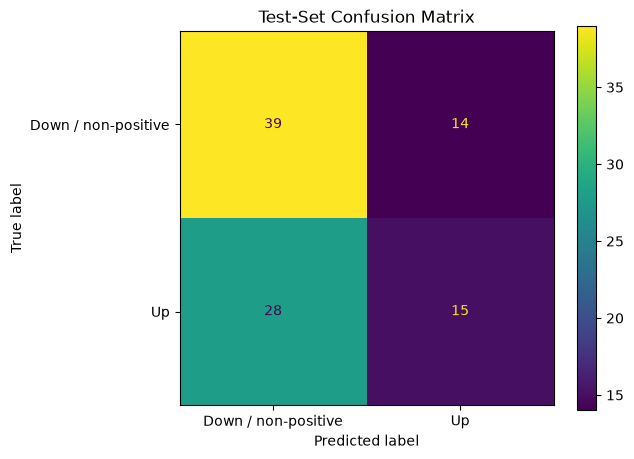

Confusion matrix:
[[39 14]
 [28 15]]


In [10]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Down / non-positive", "Up"],
)
disp.plot()
plt.title("Test-Set Confusion Matrix")
plt.tight_layout()
plt.show()

print("Confusion matrix:")
print(cm)


### Confusion-matrix interpretation

The test confusion matrix is:

\[
\begin{bmatrix}
39 & 14 \\
28 & 15
\end{bmatrix}
\]

So the model correctly identifies 39 down/non-positive observations and 15 up observations, but it produces **28 false negatives** for the up class.

This pattern explains the low recall. The classifier tends to predict the negative class more often, so the positive directional signal is not strong enough for a high-confidence decision rule.


## 9. Compare against a simple benchmark

A directional classifier should not be called useful merely because accuracy exceeds 50%. A better reference is the **majority-class test benchmark**: always predict whichever class is more common in the test period.

This benchmark is used only for interpretation; it does not replace the required logistic-regression pipeline.


In [11]:
majority_class = int(y_test.value_counts().idxmax())
majority_pred = np.full(len(y_test), majority_class)
majority_accuracy = accuracy_score(y_test, majority_pred)

comparison = pd.DataFrame({
    "model": ["Majority-class benchmark", "Logistic-regression pipeline"],
    "accuracy": [majority_accuracy, accuracy],
})

comparison


,model,accuracy
0,Majority-class benchmark,0.5521
1,Logistic-regression pipeline,0.5625


### Benchmark interpretation

The majority-class benchmark is approximately **55.2% accurate**, while logistic regression is approximately **56.3% accurate**.

That is only a very small improvement. Therefore, although the pipeline is valid and the model detects a little probability-ranking signal (`ROC-AUC > 0.5`), the evidence is not strong enough to claim a robust exploitable forecasting edge.


## 10. TimeSeriesSplit robustness check

A single chronological holdout is the required primary evaluation. As an additional robustness check, I use expanding-window `TimeSeriesSplit`.

Each validation fold occurs after its corresponding training fold, so temporal order is preserved.


In [12]:
tscv = TimeSeriesSplit(n_splits=5)

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
}

cv_results = cross_validate(
    clf,
    df_feat[feature_cols],
    df_feat["y_up"],
    cv=tscv,
    scoring=scoring,
)

cv_summary = pd.DataFrame({
    "metric": ["Accuracy", "Precision", "Recall", "F1"],
    "mean_across_5_time_folds": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
    ],
})

cv_summary


,metric,mean_across_5_time_folds
0,Accuracy,0.5165
1,Precision,0.4589
2,Recall,0.3037
3,F1,0.3577


### Cross-validation interpretation

Across five time-ordered validation folds, average performance is weaker than the final holdout result (accuracy is only around **0.52**, with a relatively low average F1).

This instability is important. It suggests that the final 56% test accuracy should not be treated as a stable structural relationship. Performance depends on the period being evaluated, which is exactly the type of risk expected under regime changes and jumps.


## 11. Predicted probability through the test period

This plot shows the model's estimated probability of an up move. The dashed 0.5 line is the default logistic-classification threshold.


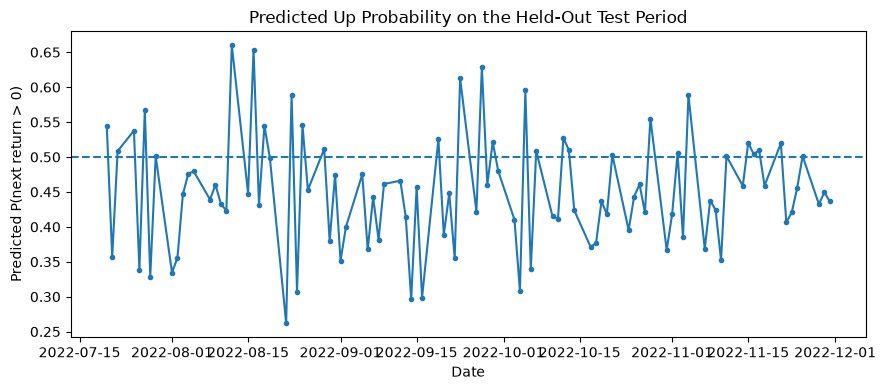

In [13]:
plt.figure(figsize=(9, 4))
plt.plot(test.index, y_prob, marker="o", markersize=3)
plt.axhline(0.5, linestyle="--")
plt.xlabel("Date")
plt.ylabel("Predicted P(next return > 0)")
plt.title("Predicted Up Probability on the Held-Out Test Period")
plt.tight_layout()
plt.show()


## 12. Interpretation: what works, what fails, and where assumptions break

### What works

The workflow itself is valid and reproducible. Features use only past information, the split respects time ordering, preprocessing is contained inside an sklearn pipeline, and evaluation is performed on unseen later observations. The model shows a small amount of directional discrimination, with test accuracy slightly above the majority benchmark and ROC-AUC modestly above 0.5.

### What fails

Predictive strength is weak. Precision is only moderate, recall is low, and F1 is substantially below accuracy. The classifier misses many positive returns. Time-series cross-validation also shows that performance is unstable across periods.

### Where assumptions may break

1. **Nonstationarity / regime change:** the starter data explicitly change mean and volatility halfway through the sample. Coefficients learned in one regime may not transfer to another.
2. **Jumps and heavy tails:** rare jump observations can have much larger magnitude than ordinary returns and may not be well represented by a simple linear log-odds model.
3. **Weak serial predictability:** lagged returns and rolling statistics do not necessarily contain enough information to predict next-period direction.
4. **Linear log-odds assumption:** logistic regression assumes the log-odds are linear in the transformed features. The true relationship may be nonlinear or state-dependent.
5. **Threshold risk:** using 0.5 is conventional but not necessarily decision-optimal. A different threshold changes precision and recall.
6. **Metric-to-decision gap:** a small improvement in classification accuracy does not automatically imply an economically useful strategy; transaction costs, turnover, slippage, and asymmetric consequences would matter in a real financial application.

### How I would extend the model

For a real project dataset, I would add economically motivated predictors such as recent realized volatility, VIX or other stress measures, interest-rate variables, and longer lag windows. I would compare logistic regression with nonlinear models, tune only inside time-aware cross-validation, and evaluate performance by regime. I would also compare against simple naive baselines before claiming practical usefulness.


## 13. Final conclusion

I would consider this model a **valid classification baseline but not a trustworthy stand-alone forecasting system**.

It satisfies the modeling workflow correctly: leakage-safe features, chronological evaluation, pipeline-based preprocessing, and appropriate classification metrics. The model reaches about **56.3% test accuracy**, but the majority benchmark is already about **55.2%**. Precision, recall, and F1 show that the gain is not broad-based, and expanding-window validation indicates unstable performance.

The main lesson is therefore not that next-period direction is reliably predictable. Instead, this exercise shows why **time-aware validation and multiple metrics are necessary**: a technically correct model can still have limited decision value when signal is weak, regimes change, and rare jumps occur.


## 14. Rubric checklist

- ✅ At least two new time-series features (six used)
- ✅ Lag, rolling mean, rolling standard deviation, momentum, and z-score features
- ✅ Explicit leakage prevention using past-only shifted inputs
- ✅ Next-step direction target
- ✅ Chronological 80/20 time-aware split
- ✅ sklearn `Pipeline`
- ✅ `StandardScaler` → `LogisticRegression`
- ✅ Accuracy
- ✅ Precision
- ✅ Recall
- ✅ F1
- ✅ Confusion matrix
- ✅ At least one results figure
- ✅ Majority-class benchmark
- ✅ Additional `TimeSeriesSplit` robustness check
- ✅ Interpretation of what works
- ✅ Interpretation of what fails
- ✅ Risk-aware discussion of regime change, jumps, stationarity, threshold choice, and practical decision risk

**Submission filename:** `homework10b_modeling-time-series-and-classification_submission.ipynb`
